LINK VIDEO GOOGLE DRIVE:

No 1 : https://drive.google.com/file/d/1HiUymQaMJ9d8gHEQVrqdyLFP7JDcwYUi/view?usp=drive_link

No 2 : https://drive.google.com/file/d/1TJbTbz0n7gKaoeZExK6dMZHTjS4bw4BB/view?usp=drive_link

No 3 : https://drive.google.com/file/d/1e1W1YgUNfTjv__x0Sm34cEI55jpjqQ5L/view?usp=drive_link

No 4 : https://drive.google.com/file/d/1bm9LYh02JL5gowSf2jYVceGUJyxo1wpS/view?usp=drive_link

## 2 A

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/data.zip'
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extract selesai!")

Extract selesai!


In [ ]:
import os

data_dir = "/content/data/data"

In [ ]:
for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.startswith('.'):
            os.remove(os.path.join(root, file))

print("File hidden sudah dihapus!")

File hidden sudah dihapus!


In [ ]:
classes = [c for c in os.listdir(data_dir) if not c.startswith('.')]
print(classes)

['Gray_Leaf_Spot', 'Common_Rust', 'Blight', 'Healthy']


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# PATH YANG BENAR
data_dir = "/content/data/data"

# Ambil hanya folder class (tanpa file aneh)
classes = [c for c in os.listdir(data_dir) if not c.startswith('.')]

image_count = {}
image_sizes = []

for cls in classes:
    class_path = os.path.join(data_dir, cls)

    # Ambil hanya file gambar (.jpg/.png)
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    image_count[cls] = len(files)

    # sampling biar cepat
    for file in files[:200]:
        img_path = os.path.join(class_path, file)
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)  # (width, height)
        except:
            continue

print("Jumlah gambar per class:")
for k, v in image_count.items():
    print(f"{k}: {v}")

Jumlah gambar per class:
Gray_Leaf_Spot: 574
Common_Rust: 1306
Blight: 1146
Healthy: 1162


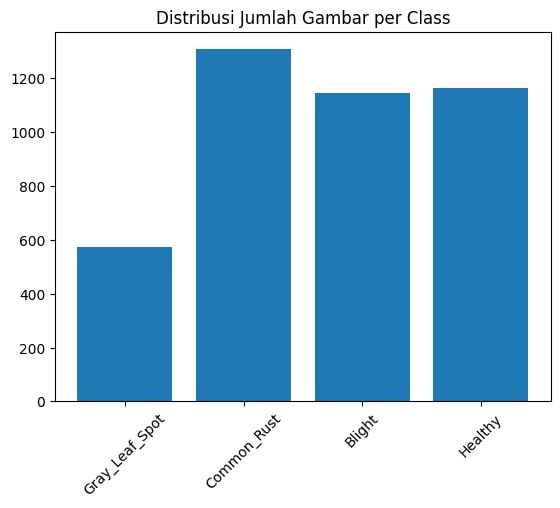

In [ ]:
plt.bar(image_count.keys(), image_count.values())
plt.title("Distribusi Jumlah Gambar per Class")
plt.xticks(rotation=45)
plt.show()

In [ ]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

print("Contoh ukuran gambar:") #cuma ambil 5 gambar pertama dari ribuan gambar
for i in range(5):
    print(image_sizes[i])

print(f"Rata-rata width: {sum(widths)/len(widths)}")
print(f"Rata-rata height: {sum(heights)/len(heights)}")

Contoh ukuran gambar:
(256, 256)
(256, 256)
(256, 256)
(256, 256)
(256, 256)
Rata-rata width: 306.6675
Rata-rata height: 298.37375


In [ ]:
aspect_ratios = [w/h for w, h in image_sizes]

print(f"Rata-rata aspect ratio: {sum(aspect_ratios)/len(aspect_ratios)}")

Rata-rata aspect ratio: 1.0219300632984263


In [ ]:
import os
import shutil
import random

random.seed(42)

# PATH YANG BENAR
base_dir = "/content/data/data"
output_dir = "/content/dataset_split"

# Ambil class yang valid
classes = [c for c in os.listdir(base_dir) if not c.startswith('.')]

splits = ["train", "val", "test"]

# Buat folder split
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# Split data
for cls in classes:
    class_path = os.path.join(base_dir, cls)

    # Ambil hanya file gambar
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    random.shuffle(images)

    total = len(images)
    train_end = int(0.7 * total)
    val_end = int(0.85 * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "test", cls, img)
        )

print("split selesai")

Split selesai!


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

base_split_dir = "/content/dataset_split"

train_dataset = datasets.ImageFolder(f"{base_split_dir}/train", transform=train_transform)
val_dataset = datasets.ImageFolder(f"{base_split_dir}/val", transform=val_test_transform)
test_dataset = datasets.ImageFolder(f"{base_split_dir}/test", transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Class index:", train_dataset.class_to_idx)

Class index: {'Blight': 0, 'Common_Rust': 1, 'Gray_Leaf_Spot': 2, 'Healthy': 3}


## 2 B

In [ ]:
import torch
import torch.nn as nn

class AlexNet(nn.Module):
    def __init__(self, num_classes=4):
        super(AlexNet, self).__init__()

        self.features = nn.Sequential(
            # Conv 1
            nn.Conv2d(3, 96, kernel_size=11, stride=4),  # 224 -> 54
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),       # 54 -> 26

            # Conv 2
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),       # 26 -> 12

            # Conv 3
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv 4
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv 5
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)        # 12 -> 5
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 5 * 5, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(4096, num_classes)  # 4 class
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AlexNet(num_classes=4).to(device)

print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6400, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch [1/10] | Train Loss: 0.7890 | Val Loss: 0.4729
Epoch [2/10] | Train Loss: 0.4812 | Val Loss: 0.4288
Epoch [3/10] | Train Loss: 0.4163 | Val Loss: 0.3883
Epoch [4/10] | Train Loss: 0.3480 | Val Loss: 0.3650
Epoch [5/10] | Train Loss: 0.3082 | Val Loss: 0.2519
Epoch [6/10] | Train Loss: 0.2741 | Val Loss: 0.2467
Epoch [7/10] | Train Loss: 0.2689 | Val Loss: 0.2374
Epoch [8/10] | Train Loss: 0.2652 | Val Loss: 0.2816
Epoch [9/10] | Train Loss: 0.2563 | Val Loss: 0.2450
Epoch [10/10] | Train Loss: 0.2267 | Val Loss: 0.2224


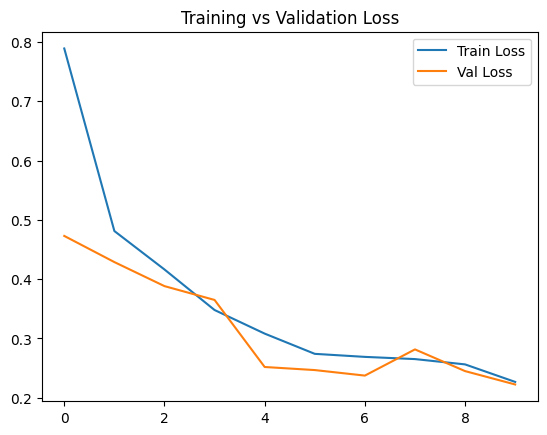

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

Selama proses training, terlihat bahwa model mengalami penurunan loss yang cukup konsisten pada data training. Pada epoch pertama, train loss berada di angka 0.7890 dan terus menurun hingga mencapai 0.2267 pada epoch ke-10. Penurunan ini menunjukkan bahwa model berhasil mempelajari pola dari data training secara efektif dan semakin mampu meminimalkan kesalahan prediksi seiring bertambahnya epoch.

Pada data validasi, val loss juga menunjukkan tren penurunan yang cukup signifikan, meskipun tidak sepenuhnya monoton. Nilai awal val loss sebesar 0.4729 menurun hingga mencapai 0.2224 pada epoch ke-10. Hal ini menunjukkan bahwa model tidak hanya belajar pada data training, tetapi juga mampu melakukan generalisasi dengan baik pada data yang belum pernah dilihat sebelumnya.

## 1 C

In [ ]:
import torch
import torch.nn as nn

class ModifiedAlexNet(nn.Module):
    def __init__(self, num_classes=4):
        super(ModifiedAlexNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),

            nn.Dropout(0.3)  # tambahan
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*5*5, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_mod = ModifiedAlexNet(num_classes=4).to(device)
print(model_mod)

ModifiedAlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Conv2d(384, 25

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_mod.parameters(),
    lr=0.00005,            # lebih kecil
    weight_decay=1e-4      # L2 regularization
)

In [ ]:
num_epochs = 10

train_losses_mod = []
val_losses_mod = []

for epoch in range(num_epochs):
    model_mod.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model_mod(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses_mod.append(train_loss)

    # VALIDATION
    model_mod.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model_mod(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    val_losses_mod.append(val_loss)

    print(f"[MOD] Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

[MOD] Epoch 1: Train Loss=0.5922, Val Loss=0.3729
[MOD] Epoch 2: Train Loss=0.3498, Val Loss=0.3935
[MOD] Epoch 3: Train Loss=0.3284, Val Loss=0.2316
[MOD] Epoch 4: Train Loss=0.2730, Val Loss=0.2822
[MOD] Epoch 5: Train Loss=0.2595, Val Loss=0.2032
[MOD] Epoch 6: Train Loss=0.2451, Val Loss=0.2651
[MOD] Epoch 7: Train Loss=0.2272, Val Loss=0.2274
[MOD] Epoch 8: Train Loss=0.2014, Val Loss=0.2463
[MOD] Epoch 9: Train Loss=0.1979, Val Loss=0.3268
[MOD] Epoch 10: Train Loss=0.1992, Val Loss=0.2449


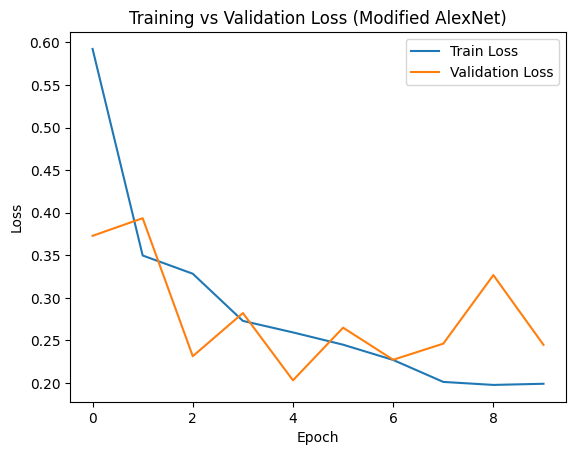

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses_mod, label='Train Loss')
plt.plot(val_losses_mod, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Modified AlexNet)")
plt.legend()

plt.show()

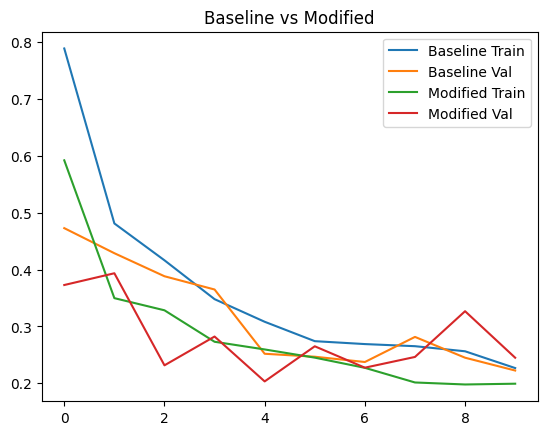

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Baseline Train')
plt.plot(val_losses, label='Baseline Val')

plt.plot(train_losses_mod, label='Modified Train')
plt.plot(val_losses_mod, label='Modified Val')

plt.legend()
plt.title("Baseline vs Modified")
plt.show()

Modifikasi pada arsitektur AlexNet dilakukan untuk meningkatkan kemampuan generalisasi model dan mengurangi risiko overfitting, sekaligus membuat proses training lebih stabil. Pada model awal, hanya digunakan layer konvolusi dan fully connected tanpa normalisasi dan regularisasi tambahan, sehingga model berpotensi terlalu cepat menghafal data training.

Beberapa perubahan utama yang dilakukan adalah

Pertama, ditambahkan Batch Normalization setelah setiap convolution layer. Tujuannya adalah menstabilkan distribusi input pada setiap layer selama training, sehingga proses pembelajaran menjadi lebih cepat dan lebih stabil.

Kedua, ditambahkan Dropout pada bagian feature extractor dan classifier. Dropout berfungsi untuk mengurangi ketergantungan model terhadap neuron tertentu dengan cara mematikan sebagian neuron secara acak selama training, sehingga model tidak mudah overfitting.

Ketiga, digunakan learning rate yang lebih kecil (0.00005) agar proses update bobot lebih baik, sehingga model dapat mencapai konvergensi yang lebih stabil.

Keempat, ditambahkan weight decay (L2 regularization) untuk memberikan penalti terhadap bobot yang terlalu besar, sehingga model menjadi lebih sederhana dan lebih general.

Pada epoch 1, model masih belajar  sehingga train loss (0.5922) dan val loss (0.3729) dan ini masih cukup tinggi. Di epoch 2, train loss turun cukup signifikan, tetapi val loss sedikit naik yang menunjukkan penyesuaian awal model belum stabil.

Mulai epoch 3 hingga 5, model menunjukkan perbaikan yang baik, ditandai dengan penurunan val loss hingga titik terendah di epoch 5 (0.2032). Ini bisa dianggap sebagai performa terbaik model karena kemampuan generalisasi paling baik terjadi di titik ini.

Setelah itu (epoch 6–10), val loss mengalami fluktuasi naik turun, meskipun train loss terus menurun. Hal ini menunjukkan model mulai sedikit fokus ke data training, tetapi tidak sampai terjadi overfitting yang parah karena val loss masih relatif stabil.

## 1 D

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro')
    rec = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    return acc, prec, rec, f1

In [ ]:
# Baseline
acc_b, prec_b, rec_b, f1_b = evaluate_model(model, test_loader)

# Modified
acc_m, prec_m, rec_m, f1_m = evaluate_model(model_mod, test_loader)

print("=== BASELINE ===")
print(f"Accuracy : {acc_b:.4f}")
print(f"Precision: {prec_b:.4f}")
print(f"Recall   : {rec_b:.4f}")
print(f"F1 Score : {f1_b:.4f}")

print("\n=== MODIFIED ===")
print(f"Accuracy : {acc_m:.4f}")
print(f"Precision: {prec_m:.4f}")
print(f"Recall   : {rec_m:.4f}")
print(f"F1 Score : {f1_m:.4f}")

=== BASELINE ===
Accuracy : 0.9127
Precision: 0.8935
Recall   : 0.8972
F1 Score : 0.8952

=== MODIFIED ===
Accuracy : 0.9079
Precision: 0.9106
Recall   : 0.8747
F1 Score : 0.8854


Berdasarkan hasil evaluasi, terlihat bahwa model baseline memiliki performa yang lebih tinggi pada beberapa metrik utama dibandingkan model modified. Accuracy pada baseline sebesar 0.9127, sedangkan modified sedikit lebih rendah yaitu 0.9079. Hal ini menunjukkan bahwa secara keseluruhan jumlah prediksi benar pada baseline sedikit lebih baik. Namun, pada metrik precision, model modified justru mengalami peningkatan menjadi 0.9106 dibandingkan baseline sebesar 0.8935, yang berarti model modified lebih baik dalam mengurangi kesalahan prediksi positif (false positive).

selain itu, recall pada model modified menurun menjadi 0.8747 dibandingkan baseline 0.8972. Penurunan ini menunjukkan bahwa model modified lebih banyak melewatkan data positif (false negative). Hal ini juga berdampak pada penurunan F1 score pada model modified menjadi 0.8854, lebih rendah dibandingkan baseline yang mencapai 0.8952. Secara keseluruhan, baseline memberikan keseimbangan yang lebih baik antara precision dan recall, sedangkan model modified lebih condong ke precision tetapi mengorbankan recall.

Meskipun demikian, model modified memiliki keunggulan dalam hal stabilitas dan potensi generalisasi yang lebih baik karena penggunaan teknik regularisasi seperti dropout, batch normalization, dan weight decay.

**Untuk pengembangan lebih lanjut**

model dapat dioptimalkan dengan melakukan tuning threshold klasifikasi agar keseimbangan antara precision dan recall dapat diperbaiki. Selain itu, hyperparameter seperti learning rate, dropout rate, dan weight decay juga dapat disesuaikan lebih lanjut. Jika dataset tidak seimbang, teknik seperti class weighting atau oversampling juga dapat digunakan.